# Cleaning

In [1]:
# Import, clean

import pandas as pd

games = pd.read_csv("data/games.csv")
matches = pd.read_csv("data/matches.csv")
tournaments = pd.read_csv("data/tour_meta.csv")

# Clean
# drop missing dates (games)
games['date'] = pd.to_datetime(games.date.str.split('(').str[0].str.strip())
games = games[pd.notna(games['date'])]
# sort by date
games.sort_values('date', inplace=True)

# clean dates (matches)
matches['date'] = pd.to_datetime(matches.date)
matches = matches[pd.notna(matches['date'])]
# sort by date
matches.sort_values('date', inplace=True)
# drop nan scores
matches = matches[pd.notna(matches['team1_score']) & pd.notna(matches['team2_score'])]

In [2]:
# Tournament attributes

import re
import pandas as pd

def map_tournament_attributes(matches: pd.DataFrame) -> pd.DataFrame:

    def get_region(name: str) -> str:
        if name.startswith("LEC"):
            return "LEC"
        if name.startswith(("LCK", "LCK Cup")):
            return "LCK"
        if name.startswith(("LPL", "LPL ")):
            return "LPL"
        if name.startswith(("LCS", "LTA", "LCP")):
            return "LCS"
        if name.startswith(("MSI", "Mid-Season Invitational")):
            return "INTL"
        if "World" in name or "Esports World Cup" in name:
            return "INTL"
        return "OTHER"

    def get_season(name: str) -> int | None:
        m = re.search(r"(20\d{2})", name)  # pl 2023/2024/2025
        return int(m.group(1)) if m else None

    def get_split(name: str) -> str:
        # Normalize split: Spring/Winter → Split1, Summer/Split2 → Split2, MSI/Worlds/EWC → International
        lowered = name.lower()
        if any(x in lowered for x in ["msi", "world", "esports world cup"]):
            return "International"
        if any(x in lowered for x in ["winter", "spring", "split 1"]):
            return "Split1"
        if any(x in lowered for x in ["summer", "split 2"]):
            return "Split2"
        return "Other"

    def get_stage(name: str) -> str:
        lowered = name.lower()
        if "groups" in lowered:
            return "Groups"
        if "playoffs" in lowered:
            return "Playoffs"
        if "regional finals" in lowered:
            return "Regional Finals"
        if "championship" in lowered:
            return "Championship"
        if "play-in" in lowered or "qualifying" in lowered:
            return "Qualifier"
        if "main event" in lowered:
            return "Main Event"
        # alap esetben Season
        if any(x in lowered for x in ["season", "split", "rounds"]):
            return "Season"
        return "Unknown"

    def is_international(name: str) -> int:
        lowered = name.lower()
        return 1 if any(x in lowered for x in ["msi", "world", "esports world cup"]) else 0

    def is_regional_final(name: str) -> int:
        return 1 if "regional finals" in name.lower() else 0

    matches["region"] = matches["tournament_name"].apply(get_region)
    matches["season"] = matches["tournament_name"].apply(get_season)
    matches["split"] = matches["tournament_name"].apply(get_split)
    matches["stage"] = matches["tournament_name"].apply(get_stage)
    matches["is_international"] = matches["tournament_name"].apply(is_international)
    matches["is_regional_final"] = matches["tournament_name"].apply(is_regional_final)

    return matches


tournaments = map_tournament_attributes(tournaments)
display(tournaments.sample(5))
print(tournaments[['tournament_name', 'region', 'season', 'split', 'stage', 'is_international', 'is_regional_final']].info())

,tournament_name,Draft mode,Number of games,Average game duration,Average kills / game,Shortest game,Longest game,Game with the most kills,url,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,region,season,split,stage,is_international,is_regional_final
9,LCS Spring Playoffs 2023,Classic,30,32:17,25.0,NaN,NaN,NaN,https://gol.gg/tournament/tournament-stats/LCS...,NaN,NaN,NaN,NaN,LCS,2023,Split1,Playoffs,0,0
34,LCS Spring 2024,Classic,57,33:22,NaN,NaN,NaN,NaN,https://gol.gg/tournament/tournament-stats/LCS...,NaN,NaN,NaN,NaN,LCS,2024,Split1,Unknown,0,0
4,LEC Spring Season 2023,Classic,46,32:31,28.0,NaN,NaN,NaN,https://gol.gg/tournament/tournament-stats/LEC...,NaN,NaN,NaN,NaN,LEC,2023,Split1,Season,0,0
79,LCK 2025 Season Play-In,Fearless Draft,21,30:17,29.0,NaN,NaN,NaN,https://gol.gg/tournament/tournament-stats/LCK...,NaN,NaN,NaN,NaN,LCK,2025,Other,Qualifier,0,0
82,Worlds 2025 Play-In,Fearless Draft,4,33:37,36.0,27:03 - T1 vs IG,NaN,NaN,https://gol.gg/tournament/tournament-stats/Wor...,NaN,NaN,NaN,NaN,INTL,2025,International,Qualifier,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   tournament_name    84 non-null     object
 1   region             84 non-null     object
 2   season             84 non-null     int64 
 3   split              84 non-null     object
 4   stage              84 non-null     object
 5   is_international   84 non-null     int64 
 6   is_regional_final  84 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 4.7+ KB
None


In [3]:
# ELO calc

import pandas as pd

matches = pd.merge(matches, tournaments[['tournament_name', 'region', 'is_international']], 
                   how='left', on='tournament_name')

# kezdő ELO minden csapatnak
initial_elo = 1500
# példa: ligánként eltérő kezdő ELO
league_base_elo = {
    "LPL": 1550,
    "LCK": 1550,
    "LEC": 1525,
    "LCS": 1500,
    "LTA": 1450,
    "LCP": 1450,
    "MSI": 1580,  # ha nemzetközi bónusz
    "Worlds": 1600
}
K = 20  # standard K érték, meccsenként

# létrehozunk egy dictionary-t a csapatok ELO-jához
team_elos = {}

# új oszlopok a matches-hez
matches['team1_elo_before'] = 0
matches['team2_elo_before'] = 0
matches['team1_elo_after'] = 0
matches['team2_elo_after'] = 0

# Liga matchup korrekció: international meccsekből számoljuk
international_matches = matches[matches.get('is_international', 0) == 1]

# Liga matchup dict létrehozása
league_correction = {}  # pl. ('LPL','LEC') -> +20
for idx, row in international_matches.iterrows():
    l1, l2 = row['region'], row['region']  # ha külön kell: team1_region, team2_region
    l1, l2 = row['team1_region'] if 'team1_region' in row else l1, row['team2_region'] if 'team2_region' in row else l2
    key = (l1, l2)
    league_correction.setdefault(key, []).append(1 if row['team1_score'] > row['team2_score'] else 0)

# Átlagos korrekció számítása
for k in league_correction:
    # winrate: 0-1 → átalakítjuk Elo pontban, pl. *100
    league_correction[k] = (sum(league_correction[k]) / len(league_correction[k]) - 0.5) * 200  

# rendezzük időrendbe
matches = matches.sort_values('date').reset_index(drop=True)

for idx, row in matches.iterrows():
    t1 = row['team1']
    t2 = row['team2']
    league1 = row['region']
    league2 = row['region']
    
    if t1 not in team_elos:
        base = league_base_elo.get(league1, initial_elo)
        team_elos[t1] = base
    if t2 not in team_elos:
        base = league_base_elo.get(league2, initial_elo)
        team_elos[t2] = base

    elo1 = team_elos[t1]
    elo2 = team_elos[t2]

    matches.at[idx, 'team1_elo_before'] = elo1
    matches.at[idx, 'team2_elo_before'] = elo2

    # Liga matchup korrekció hozzáadása
    correction = league_correction.get((league1, league2), 0)
    
    expected1 = 1 / (1 + 10 ** (((elo2 - elo1) - correction) / 400))
    expected2 = 1 / (1 + 10 ** (((elo1 - elo2) + correction) / 400))

    if row['team1_score'] > row['team2_score']:
        s1, s2 = 1, 0
    else:
        s1, s2 = 0, 1

    elo1_new = elo1 + K * (s1 - expected1)
    elo2_new = elo2 + K * (s2 - expected2)

    team_elos[t1] = elo1_new
    team_elos[t2] = elo2_new

    matches.at[idx, 'team1_elo_after'] = elo1_new
    matches.at[idx, 'team2_elo_after'] = elo2_new

team_elos

C:\Users\Adam\AppData\Local\Temp\ipykernel_40328\3927025078.py:87: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1530.5750112778453' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matches.at[idx, 'team1_elo_after'] = elo1_new
C:\Users\Adam\AppData\Local\Temp\ipykernel_40328\3927025078.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1569.4249887221547' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matches.at[idx, 'team2_elo_after'] = elo2_new
C:\Users\Adam\AppData\Local\Temp\ipykernel_40328\3927025078.py:67: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1530.5750112778453' has dtype incompatible with int64, please explicitly cast to a compatible dtype fi

{'Anyone s Legend': 1802.4401605575017,
 'Invictus Gaming': 1618.940221910414,
 'Bilibili Gaming': 1832.8004280151672,
 'JD Gaming': 1739.0591083721363,
 'Funplus Phoenix': 1523.397340745046,
 'Team WE': 1487.7390620376848,
 'LGD Gaming': 1459.8322885144341,
 'Rare Atom': 1459.8023792853485,
 'Royal Never Give Up': 1326.0211437601806,
 'OMG': 1470.6962497961204,
 'Ultra Prime': 1325.824386183927,
 'Ninjas in Pyjamas': 1490.9716859714142,
 'Edward Gaming': 1442.4855983017471,
 'Top Esports': 1858.7899193866044,
 'TT': 1481.4084242019785,
 'LNG Esports': 1638.452684362138,
 'Weibo Gaming': 1646.216891431388,
 'T1': 1824.0453161915698,
 'Gen.G eSports': 2033.1569454024252,
 'Dplus KIA': 1675.1554009915803,
 'DRX': 1400.980603313602,
 'Kwangdong Freecs': 1434.6877450464763,
 'Hanwha Life eSports': 1842.607955731425,
 'Nongshim RedForce': 1498.0319758983949,
 'BRION': 1379.544063695526,
 'KT Rolster': 1714.3936937100475,
 'Liiv SANDBOX': 1417.8291275805677,
 'Excel Esports': 1506.0176305933

In [ ]:
# ELO visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1️⃣ ELO rangsor jelenleg
# -------------------------------
# Kiszámítjuk a végső ELO-t minden csapatra (utolsó meccs után)
elo_latest_team1 = matches.groupby('team1')['team1_elo_after'].last()
elo_latest_team2 = matches.groupby('team2')['team2_elo_after'].last()

elo_latest = pd.concat([elo_latest_team1, elo_latest_team2], axis=1)
elo_latest['final_elo'] = elo_latest.max(axis=1)
elo_rank = elo_latest['final_elo'].sort_values(ascending=False)
print("=== Jelenlegi ELO rangsor ===")
print(elo_rank.head(10))

# -------------------------------
# 2️⃣ Upset / meglepetés meccsek
# -------------------------------
# Definiáljuk, hogy upset, ha a győztes ELO-ja legalább 100 ponttal kevesebb volt a vesztesnél
def detect_upset(row):
    if row['team1_score'] > row['team2_score'] and row['team1_elo_after'] + 100 < row['team2_elo_after']:
        return True
    elif row['team2_score'] > row['team1_score'] and row['team2_elo_after'] + 100 < row['team1_elo_after']:
        return True
    else:
        return False

matches['upset'] = matches.apply(detect_upset, axis=1)
num_upsets = matches['upset'].sum()
print(f"Number of upsets: {num_upsets}")

# -------------------------------
# 3️⃣ Ligánkénti ELO trend
# -------------------------------
plt.figure(figsize=(14,6))
sns.lineplot(data=matches, x='date', y='team1_elo_after', hue='team1', alpha=0.5)
plt.title("ELO trend csapatonként ligánként (team1 ELO)")
plt.xlabel("Date")
plt.ylabel("ELO")
plt.legend([],[], frameon=False)  # túl sok csapat, ezért elrejtjük a legend-et
plt.show()

# -------------------------------
# 4️⃣ ELO boxplot csapatonként
# -------------------------------
plt.figure(figsize=(16,6))
top_teams = matches['team1'].value_counts().nlargest(10).index  # Top 10 gyakori csapat
sns.boxplot(data=matches[matches['team1'].isin(top_teams)], x='team1', y='team1_elo_after')
plt.title("ELO boxplot csapatonként (top 10 gyakori csapat)")
plt.xlabel("Team")
plt.ylabel("ELO")
plt.xticks(rotation=45)
plt.show()

# Odds

## OddsPortal

In [ ]:
# Tournaments

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time

def scrape_oddsportal_lol_links():
    url = "https://www.oddsportal.com/results/#esports"
    driver = webdriver.Chrome()
    driver.get(url)

    wait = WebDriverWait(driver, 15)
    # várjuk, amíg betöltődik legalább 1 tournament link
    wait.until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, "li[data-testid='results-tournament-box'] a")))

    time.sleep(2)  # kis extra wait, hogy minden JS lefusson

    links = driver.find_elements(By.CSS_SELECTOR, "li[data-testid='results-tournament-box'] a")

    data = []
    for link in links:
        try:
            text = link.text.strip()
            href = link.get_attribute("href")
            if text.startswith("League of Legends "):
                name = text.replace("League of Legends ", "").strip()
                data.append({
                    "Name": name,
                    "url": href
                })
        except Exception as e:
            print(f"⚠️ Hiba egy link feldolgozásánál: {e}")
            continue

    driver.quit()
    df = pd.DataFrame(data)
    print(f"✅ {len(df)} League of Legends esemény található az OddsPortalon.")
    return df


# --- Példa futtatás ---
df_oddsportal = scrape_oddsportal_lol_links()
display(df_oddsportal)


In [ ]:
# Odds of tournament

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import re, time
from datetime import datetime

def scrape_oddsportal_fixed(event_url, headless=False):
    opts = webdriver.ChromeOptions()
    if headless:
        opts.add_argument("--headless=new")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("user-agent=Mozilla/5.0")
    
    driver = webdriver.Chrome(options=opts)
    driver.get(event_url)
    wait = WebDriverWait(driver, 20)

    # --- Cookie gomb elfogadása, ha van ---
    try:
        cookie_btn = wait.until(EC.element_to_be_clickable((By.ID, "onetrust-accept-btn-handler")))
        cookie_btn.click()
        time.sleep(1)
        print("🍪 Cookie elfogadva")
    except:
        pass

    # --- 2023 és 2024 szezon linkek lekérdezése ---
    season_links = driver.find_elements(By.CSS_SELECTOR, "a[href*='/results/']")
    season_urls = []
    season_urls.append(event_url)
    for a in season_links:
        href = a.get_attribute("href")
        if re.search(r'2023/results/', href) or re.search(r'2024/results/', href):
            season_urls.append(href)

    # Ha nincs külön link, használjuk az eredeti event_url-t
    if not season_urls:
        season_urls = [event_url]

    all_data = []

    # --- Iterálunk a szezon linkeken ---
    for season_url in season_urls:
        driver.get(season_url)
        time.sleep(2)
        print(f"📅 Szezon feldolgozása: {season_url}")

        page = 1
        while True:
            print(f"🔍 Oldal {page} feldolgozása...")
            
            # Inkrementális scroll: lépésekben, lassabban
            scroll_pause = 1.5
            scroll_step = 500  # pixelenként
            last_height = driver.execute_script("return document.body.scrollHeight")
            current_pos = 0

            while current_pos < last_height:
                driver.execute_script(f"window.scrollTo(0, {current_pos});")
                time.sleep(scroll_pause)
                current_pos += scroll_step
                new_height = driver.execute_script("return document.body.scrollHeight")
                if new_height > last_height:
                    last_height = new_height


            time.sleep(2)
            wait.until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, "div.eventRow")))

            event_rows = driver.find_elements(By.CSS_SELECTOR, "div.eventRow")
            current_date = None

            for event in event_rows:
                # dátum keresése
                date_found = False
                
                # Dátum keresése az event teljes szövegében
                date_text = event.text.strip()
                if any(month in date_text for month in ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']):
                    lines = date_text.split('\n')
                    for line in lines:
                        if any(month in line for month in ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']):
                            # Dátum formázása - eltávolítjuk a " -" utáni részt
                            clean_date = line.split(' -')[0].strip()
                            current_date = clean_date
                            
                            # Dátum átalakítása YYYY-MM-dd formátumba
                            try:
                                date_obj = datetime.strptime(current_date, '%d %b %Y')
                                current_date = date_obj.strftime('%Y-%m-%d')
                            except ValueError:
                                # Ha nem sikerül átalakítani, marad az eredeti
                                pass
                            
                            date_found = True
                            break

                # Ha nincs dátum, de van game-row, akkor meccs sor
                try:
                    game_row = event.find_element(By.CSS_SELECTOR, "div[data-testid='game-row']")
                except:
                    continue

                # csapatnevek
                participants = game_row.find_elements(By.CSS_SELECTOR, "a[title]")
                if len(participants) < 2:
                    continue

                home_team = participants[0].get_attribute("title").strip()
                away_team = participants[1].get_attribute("title").strip()

                # oddsok
                odds_blocks = event.find_elements(By.CSS_SELECTOR, "div[data-testid^='odd-container'] p")
                odds = []
                for p in odds_blocks:
                    try:
                        odds_text = p.text.strip().replace(",", ".")
                        if re.match(r"^\d+(\.\d+)?$", odds_text):
                            odds.append(float(odds_text))
                    except:
                        continue
                
                home_odds = odds[0] if len(odds) > 0 else None
                away_odds = odds[1] if len(odds) > 1 else None

                all_data.append({
                    "Date": current_date,
                    "home_team": home_team,
                    "away_team": away_team,
                    "home_odds": home_odds,
                    "away_odds": away_odds
                })

            # Következő oldal ellenőrzése
            try:
                next_button = driver.find_element(By.CSS_SELECTOR, f"a.pagination-link[data-number='{page + 1}']")
                if next_button.is_enabled():
                    print(f"➡️ Következő oldal: {page + 1}")
                    driver.execute_script("arguments[0].click();", next_button)
                    page += 1
                    time.sleep(3)  # Várakozás az oldal betöltésére
                    continue
                else:
                    break
            except:
                # Ha nincs következő oldal, kilépünk
                break

    driver.quit()
    
    df = pd.DataFrame(all_data).drop_duplicates(subset=["home_team","away_team","home_odds","away_odds"])
    print(f"✅ Összesen {len(df)} meccs feldolgozva {page} oldalról.")
    return df

# Teszt
#url = "https://www.oddsportal.com/esports/league-of-legends/league-of-legends-world-championship/results/"
#df_odds = scrape_oddsportal_fixed(url, headless=False)
#display(df_odds)

In [ ]:
# Relevant odds
  
oddsportal_relevant = [
    "LEC",
    "LCS Lock-In",
    "LTA North",
    "LTA South",
    "LTA Cross Conference",
    "LCP",
    "LCK",
    "LPL",
    "World Championship",
    "Esports World Cup"
]

df_odds_super = pd.DataFrame()
for op_tour in oddsportal_relevant:
    url_op = df_oddsportal[df_oddsportal.Name == op_tour]['url'].iloc[0]
    df_odds = scrape_oddsportal_fixed(url_op, headless=False)
    df_odds['tournament_op'] = op_tour
    df_odds_super = pd.concat([df_odds_super, df_odds], ignore_index=True)

display(df_odds_super)

In [ ]:
# Save odds super

df_odds_super['Date'] = pd.to_datetime(df_odds_super['Date'])
df_odds_super.sort_values('Date', inplace=True)
df_odds_super = df_odds_super.reset_index(drop=True)
display(df_odds_super)

df_odds_super.to_csv('data/odds.csv', index=False)

## Fuzzy match

In [ ]:
# Fuzzy matching JSON

import pandas as pd
from fuzzywuzzy import process
import json
from pathlib import Path
import re

# --- Helper függvény: normalizálás ---
def normalize_team_name(name):
    name = name.lower()
    # eltávolítjuk a 'team', 'gaming', 'esports' szavakat
    name = re.sub(r'\b(team|gaming|esports)\b', '', name)
    # extra whitespace eltávolítás
    name = re.sub(r'\s+', ' ', name).strip()
    return name

# --- Egyedi csapatnevek ---
odds_teams = pd.unique(df_odds_super[['home_team','away_team']].values.ravel())
match_teams = pd.unique(matches[['team1','team2']].values.ravel())

# --- Normalizált változatok készítése fuzzyhoz ---
normalized_match_teams = {normalize_team_name(t): t for t in match_teams}

team_mapping = {}
for team in odds_teams:
    norm_team = normalize_team_name(team)
    
    # fuzzy match a normalizált neveken
    best_match_norm, score = process.extractOne(norm_team, normalized_match_teams.keys())
    # visszakapjuk az eredeti matches csapatnevet
    matched_team = normalized_match_teams[best_match_norm]
    
    team_mapping[team] = {
        "matched_team": matched_team,
        "score": score
    }

# --- Mentés JSON-ba ---
#Path("data").mkdir(exist_ok=True)
#with open("data/team_name_mapping.json", "w", encoding="utf-8") as f:
#    json.dump(team_mapping, f, indent=2, ensure_ascii=False)

#print("✅ Normalizált fuzzy team mapping kész, elmentve: data/team_name_mapping.json")


In [4]:
# Map team names

import json

with open("data/team_name_mapping.json", "r", encoding="utf-8") as f:
    team_mapping = json.load(f)

df_odds_super = pd.read_csv('data/odds.csv')

for i, row in df_odds_super.iterrows():
    df_odds_super.loc[i, 'team1'] = team_mapping[row['home_team']]['matched_team']
    df_odds_super.loc[i, 'team2'] = team_mapping[row['away_team']]['matched_team']


# Matches mapping
## convert name and type
df_odds_super.rename(columns={'Date': 'date'}, inplace=True)
df_odds_super['date'] = pd.to_datetime(df_odds_super['date'])

## merge manually
for i, row in df_odds_super.iterrows():
    home_op = row['team1']
    away_op = row['team2']

    rel_matches = matches[(matches.date < row['date'] + pd.Timedelta(days=1)) & 
                          (matches.date > row['date'] - pd.Timedelta(days=1))]
    if rel_matches.shape[0] == 0:
        continue
    else:
        for j, match in rel_matches.iterrows():
            if home_op == match['team1'] and away_op == match['team2']:
                matches.loc[j, 'team1_odds'] = row['home_odds']
                matches.loc[j, 'team2_odds'] = row['away_odds']
            elif home_op == match['team2'] and away_op == match['team1']:
                matches.loc[j, 'team1_odds'] = row['away_odds']
                matches.loc[j, 'team2_odds'] = row['home_odds']

matches_o = matches[matches.team1_odds.notna()].reset_index(drop=True).copy()
display(matches_o.sample(7))
print(f"Matches with matched odds: {len(matches_o)}/{len(matches)}")

,tournament_name,match_id,match_name,team1,team1_score,team2,team2_score,total_games,week,patch,date,url,region,is_international,team1_elo_before,team2_elo_before,team1_elo_after,team2_elo_after,team1_odds,team2_odds
282,LPL 2025 Split 2,66538,AL vs JD Gaming,Anyone s Legend,0.0,JD Gaming,2.0,2,WEEK4,15.8,2025-04-24,https://gol.gg/game/stats/66538/page-summary/,LPL,0,1667.648846,1752.178720,1660.034916,1759.792650,1.54,2.39
447,LCK 2025 Rounds 1-2,68739,Dplus KIA vs KT Rolster,Dplus KIA,1.0,KT Rolster,2.0,3,TIEBREAKERS,15.1,2025-06-04,https://gol.gg/game/stats/68739/page-summary/,LCK,0,1710.358678,1650.097638,1698.088814,1662.367502,1.67,2.14
62,LEC Winter 2025,63498,VIT vs KC,Team Vitality,0.0,Karmine Corp,1.0,1,WEEK3,15.2,2025-02-01,https://gol.gg/game/stats/63498/page-game/,LEC,0,1455.652355,1511.812013,1447.254828,1520.209540,3.20,1.32
4,LCK Cup 2025,62970,DN Freecs vs NS,DN Freecs,2.0,Nongshim RedForce,1.0,3,WEEK1,15.1,2025-01-15,https://gol.gg/game/stats/62970/page-summary/,LCK,0,1550.000000,1395.879939,1555.369728,1390.510211,1.52,2.43
176,LPL 2025 Split 2 Placements,65363,FPX vs Ultra Prime,Funplus Phoenix,2.0,Ultra Prime,1.0,3,ROUND2,15.6,2025-03-30,https://gol.gg/game/stats/65363/page-summary/,LPL,0,1548.727645,1321.420304,1552.982451,1317.165499,1.86,1.88
149,LPL 2025 Split 2 Placements,65359,EDG vs Team WE,Edward Gaming,0.0,Team WE,1.0,1,TIEBREAKERS,15.6,2025-03-26,https://gol.gg/game/stats/65359/page-game/,LPL,0,1422.729681,1389.210116,1411.767892,1400.171904,1.37,2.95
439,LEC 2025 Spring Playoffs,68549,KC vs TH,Karmine Corp,3.0,Team Heretics,1.0,4,ROUND1,15.1,2025-06-01,https://gol.gg/game/stats/68549/page-summary/,LEC,0,1566.663616,1472.136524,1574.008109,1464.792031,1.06,8.35


Matches with matched odds: 584/5200


# ML

In [26]:
# ML features

import numpy as np

# --- 1️⃣ Tournament info integrálása matches_o-ba ---
ml_matches = matches.copy()

# Merge tournament metadata
ml_matches = pd.merge(ml_matches,
    tournaments[['tournament_name', 'region', 'split', 'stage']],
    how='left',
    on='tournament_name'
)

# --- 2️⃣ Elo alapú feature-ök ---
ml_matches['elo_diff'] = ml_matches['team1_elo_before'] - ml_matches['team2_elo_before']

# --- 3️⃣ Forma / momentum feature-ök ---
ml_matches = ml_matches.sort_values('date')
ml_matches['team1_win'] = (ml_matches['team1_score'] > ml_matches['team2_score']).astype(int)
ml_matches['team2_win'] = (ml_matches['team2_score'] > ml_matches['team1_score']).astype(int)

# Rolling window 5 meccs soronként
def rolling_winrate_rowwise(df, n=5):
    team1_winrates = []
    team2_winrates = []

    df_sorted = df.sort_values('date')

    for idx, row in df_sorted.iterrows():
        team1 = row['team1']
        team2 = row['team2']
        date = row['date']

        # --- Team1 winrate ---
        past_team1 = df_sorted[
            ((df_sorted['team1'] == team1) | (df_sorted['team2'] == team1)) &
            (df_sorted['date'] < date)
        ].sort_values('date', ascending=False).head(n)
        if len(past_team1) == 0:
            team1_winrates.append(np.nan)
        else:
            wins = sum(
                (m['team1_win'] if m['team1'] == team1 else m['team2_win'])
                for _, m in past_team1.iterrows()
            )
            team1_winrates.append(wins / len(past_team1))

        # --- Team2 winrate ---
        past_team2 = df_sorted[
            ((df_sorted['team1'] == team2) | (df_sorted['team2'] == team2)) &
            (df_sorted['date'] < date)
        ].sort_values('date', ascending=False).head(n)
        if len(past_team2) == 0:
            team2_winrates.append(np.nan)
        else:
            wins = sum(
                (m['team1_win'] if m['team1'] == team2 else m['team2_win'])
                for _, m in past_team2.iterrows()
            )
            team2_winrates.append(wins / len(past_team2))

    return team1_winrates, team2_winrates

ml_matches['team1_winrate_5'], ml_matches['team2_winrate_5'] = rolling_winrate_rowwise(ml_matches, n=5)
ml_matches['team1_winrate_10'], ml_matches['team2_winrate_10'] = rolling_winrate_rowwise(ml_matches, n=10)

# --- 4️⃣ BO / patch / stage feature-ök ---
ml_matches['patch'] = ml_matches['patch'].astype(str)
ml_matches['is_playoffs'] = ml_matches['tournament_name'].str.contains('Playoffs|Finals|Championship', case=False).astype(int)

# --- 5️⃣ Games statisztika aggregálás (match szintre) ---
def assign_team_sides(row, team1, team2):
    """
    Kiszámolja a statisztikákat a megadott csapatra,
    függetlenül attól, hogy blue vagy red oldalon játszott.
    """
    result = {}
    
    # HA A CSAPAT BLUE OLDALON VOLT
    if row['blue_team'] == team1:
        result['team1_gold_diff_15min'] = row['gold_diff_15min']
        result['team1_first_blood'] = int(row['blue_first_blood'])
        result['team1_first_tower'] = int(row['blue_first_tower'])
        result['team1_barons'] = row['blue_barons']
        result['team1_dragons'] = row['blue_dragons']
        result['team1_wards_destroyed'] = row['vision_team1_wards_destroyed']
        result['team1_wards_placed'] = row['vision_team1_wards_placed']
    # HA A CSAPAT RED OLDALON VOLT
    elif row['red_team'] == team1:
        result['team1_gold_diff_15min'] = -row['gold_diff_15min']
        result['team1_first_blood'] = int(row['red_first_blood'])
        result['team1_first_tower'] = int(row['red_first_tower'])
        result['team1_barons'] = row['red_barons']
        result['team1_dragons'] = row['red_dragons']
        result['team1_wards_destroyed'] = row['vision_team2_wards_destroyed']
        result['team1_wards_placed'] = row['vision_team2_wards_placed']
    else:
        # Ha a csapat nem szerepel ebben a game-ben
        result = {f'team1_{k}': 0 for k in ['gold_diff_15min', 'first_blood', 'first_tower', 'barons', 'dragons', 'wards_destroyed', 'wards_placed']}
    
    # UGYANEZ TEAM2-RE (ha kell)
    if team2 != 'dummy':  # dummy jelzi, hogy csak team1-et számolunk
        if row['blue_team'] == team2:
            result['team2_gold_diff_15min'] = row['gold_diff_15min']
            result['team2_first_blood'] = int(row['blue_first_blood'])
            result['team2_first_tower'] = int(row['blue_first_tower'])
            result['team2_barons'] = row['blue_barons']
            result['team2_dragons'] = row['blue_dragons']
            result['team2_wards_destroyed'] = row['vision_team1_wards_destroyed']
            result['team2_wards_placed'] = row['vision_team1_wards_placed']
        elif row['red_team'] == team2:
            result['team2_gold_diff_15min'] = -row['gold_diff_15min']
            result['team2_first_blood'] = int(row['red_first_blood'])
            result['team2_first_tower'] = int(row['red_first_tower'])
            result['team2_barons'] = row['red_barons']
            result['team2_dragons'] = row['red_dragons']
            result['team2_wards_destroyed'] = row['vision_team2_wards_destroyed']
            result['team2_wards_placed'] = row['vision_team2_wards_placed']
        else:
            result.update({f'team2_{k}': 0 for k in ['gold_diff_15min', 'first_blood', 'first_tower', 'barons', 'dragons', 'wards_destroyed', 'wards_placed']})
    
    return pd.Series(result)

# Merge minden match_id-re - CSAK MÚLTBELI MECCSEK
all_features = []
n_past_matches = 3  # hány korábbi meccset átlagolsz

for idx, match in ml_matches.iterrows():
    team1 = match['team1']
    team2 = match['team2']
    current_date = match['date']
    
    # ✅ TEAM1 múltbeli game-jei (n darab meccs)
    past_matches_team1 = ml_matches[
        ((ml_matches['team1'] == team1) | (ml_matches['team2'] == team1)) &
        (ml_matches['date'] < current_date)  # ✅ CSAK MÚLT
    ].sort_values('date', ascending=False).head(n_past_matches)
    past_games_team1 = games[games['match_id'].isin(past_matches_team1['match_id'])]
    
    # ✅ TEAM1 ellenfelek ELO (átlag + szórás)
    if len(past_matches_team1) > 0:
        # ellenfél = ha team1 volt team1 -> team2_elo_before, ha team1 volt team2 -> team1_elo_before
        opponent_elos_team1 = past_matches_team1.apply(
            lambda m: m['team2_elo_before'] if m['team1'] == team1 else m['team1_elo_before'],
            axis=1
        )
        team1_opp_elo_mean = opponent_elos_team1.mean()
        team1_opp_elo_std = opponent_elos_team1.std()
        
        opponent_elodiffs_team1 = past_matches_team1.apply(
            lambda m: m['team2_elo_before'] - m['team1_elo_before'] if m['team1'] == team1 else m['team1_elo_before'] - m['team2_elo_before'],
            axis=1
        )
        team1_opp_elodiff_mean = opponent_elodiffs_team1.mean()
        team1_opp_elodiff_std = opponent_elodiffs_team1.std()
    else:
        team1_opp_elo_mean = 0
        team1_opp_elo_std = 0
        team1_opp_elodiff_mean = 0
        team1_opp_elodiff_std = 0

    # ✅ TEAM2 múltbeli game-jei
    past_matches_team2 = ml_matches[
        ((ml_matches['team1'] == team2) | (ml_matches['team2'] == team2)) &
        (ml_matches['date'] < current_date)
    ].sort_values('date', ascending=False).head(n_past_matches)
    
    past_games_team2 = games[games['match_id'].isin(past_matches_team2['match_id'])]
    
    # ✅ TEAM2 ellenfelek ELO (átlag + szórás)
    if len(past_matches_team2) > 0:
        opponent_elos_team2 = past_matches_team2.apply(
            lambda m: m['team2_elo_before'] if m['team1'] == team2 else m['team1_elo_before'],
            axis=1
        )
        team2_opp_elo_mean = opponent_elos_team2.mean()
        team2_opp_elo_std = opponent_elos_team2.std()

        opponent_elodiffs_team2 = past_matches_team2.apply(
            lambda m: m['team2_elo_before'] - m['team1_elo_before'] if m['team1'] == team2 else m['team1_elo_before'] - m['team2_elo_before'],
            axis=1
        )
        team2_opp_elodiff_mean = opponent_elodiffs_team2.mean()
        team2_opp_elodiff_std = opponent_elodiffs_team2.std()
    else:
        team2_opp_elo_mean = 0
        team2_opp_elo_std = 0
        team2_opp_elodiff_mean = 0
        team2_opp_elodiff_std = 0

    # Aggregálás team1-re
    if len(past_games_team1) > 0:
        temp1 = past_games_team1.apply(assign_team_sides, axis=1, team1=team1, team2='dummy')
        team1_stats = temp1.mean()
    else:
        team1_stats = pd.Series({col: 0 for col in [
            'team1_gold_diff_15min', 'team1_first_blood', 'team1_first_tower',
            'team1_barons', 'team1_dragons', 'team1_wards_destroyed', 'team1_wards_placed'
        ]})
    
    # Aggregálás team2-re
    if len(past_games_team2) > 0:
        temp2 = past_games_team2.apply(assign_team_sides, axis=1, team1='dummy', team2=team2)
        team2_stats = temp2.mean()
    else:
        team2_stats = pd.Series({col: 0 for col in [
            'team2_gold_diff_15min', 'team2_first_blood', 'team2_first_tower',
            'team2_barons', 'team2_dragons', 'team2_wards_destroyed', 'team2_wards_placed'
        ]})
    
    # Kombinálás - DICT-KÉ ALAKÍTÁS
    combined_dict = {**team1_stats.to_dict(), **team2_stats.to_dict()}
    combined_dict['team1_opponent_elo_mean'] = team1_opp_elo_mean
    combined_dict['team1_opponent_elo_std'] = team1_opp_elo_std
    combined_dict['team2_opponent_elo_mean'] = team2_opp_elo_mean
    combined_dict['team2_opponent_elo_std'] = team2_opp_elo_std
    combined_dict['team1_opponent_elodiff_mean'] = team1_opp_elodiff_mean
    combined_dict['team1_opponent_elodiff_std'] = team1_opp_elodiff_std
    combined_dict['team2_opponent_elodiff_mean'] = team2_opp_elodiff_mean
    combined_dict['team2_opponent_elodiff_std'] = team2_opp_elodiff_std
    combined_dict['match_id'] = match['match_id']
    all_features.append(combined_dict)

games_agg_corrected = pd.DataFrame(all_features)
match_agg_corrected = games_agg_corrected.groupby('match_id', as_index=False).mean()

ml_matches = ml_matches.merge(match_agg_corrected, on='match_id', how='left')

# --- 6️⃣ Vision és objective control arányok ---
ml_matches['team1_vision_control'] = ml_matches['team1_wards_destroyed'] / (ml_matches['team1_wards_placed'] + 1)
ml_matches['team2_vision_control'] = ml_matches['team2_wards_destroyed'] / (ml_matches['team2_wards_placed'] + 1)

ml_matches['team1_dragon_control'] = ml_matches['team1_dragons'] / (ml_matches['team1_dragons'] + ml_matches['team2_dragons'] + 1)
ml_matches['team2_dragon_control'] = ml_matches['team2_dragons'] / (ml_matches['team1_dragons'] + ml_matches['team2_dragons'] + 1)

ml_matches['team1_baron_control'] = ml_matches['team1_barons'] / (ml_matches['team1_barons'] + ml_matches['team2_barons'] + 1)
ml_matches['team2_baron_control'] = ml_matches['team2_barons'] / (ml_matches['team1_barons'] + ml_matches['team2_barons'] + 1)

# --- 7️⃣ Kimenetel target --- 
ml_matches['target'] = (ml_matches['team1_score'] > ml_matches['team2_score']).astype(int)

# --- 8️⃣ ML input kész ---
ml_features = [
    'team1_elo_before', 'team2_elo_before', 'elo_diff',
    'team1_opponent_elo_mean', 'team2_opponent_elo_mean',
    'team1_opponent_elo_std', 'team2_opponent_elo_std',
    #'team1_opponent_elodiff_mean', 'team2_opponent_elodiff_mean',
    #'team1_opponent_elodiff_std', 'team2_opponent_elodiff_std',
    'team1_winrate_5', 'team2_winrate_5',
    'team1_winrate_10', 'team2_winrate_10',
    'patch', 'is_playoffs', 'is_international',
    'team1_vision_control', 'team2_vision_control',
    'team1_dragon_control', 'team2_dragon_control',
    'team1_baron_control', 'team2_baron_control'
]

ml_df = ml_matches[ml_features + ['target', 'match_id', 'date', 'tournament_name', 'team1', 'team2']].copy()
ml_df.fillna(0, inplace=True)

print("✅ ML input kész, shape:", ml_df.shape)
display(ml_df.tail())

✅ ML input kész, shape: (5200, 26)


,team1_elo_before,team2_elo_before,elo_diff,team1_opponent_elo_mean,team2_opponent_elo_mean,team1_opponent_elo_std,team2_opponent_elo_std,team1_winrate_5,team2_winrate_5,team1_winrate_10,...,team1_dragon_control,team2_dragon_control,team1_baron_control,team2_baron_control,target,match_id,date,tournament_name,team1,team2
5195,1839.602531,1501.491648,338.110883,1656.362009,1604.338371,99.502698,73.147250,0.6,0.4,0.6,...,0.0,0.583333,0.0,0.000000,1,72927,2025-10-24,Worlds 2025 Main Event,Bilibili Gaming,Vivo Keyd Stars
5196,1569.210457,1814.072329,-244.861872,1855.373441,1777.345798,18.236511,217.263513,0.4,0.4,0.5,...,0.0,0.625000,0.0,0.400000,0,72930,2025-10-24,Worlds 2025 Main Event,100 Thieves,T1
5197,1849.818316,1841.772031,8.046285,1768.032398,1637.637342,234.031312,128.439854,0.4,0.6,0.6,...,0.0,0.666667,0.0,0.500000,1,72947,2025-10-25,Worlds 2025 Main Event,Top Esports,Bilibili Gaming
5198,1623.058434,1818.528246,-195.469812,1646.797296,1736.295369,104.755817,250.449082,0.6,0.6,0.6,...,0.0,0.714286,0.0,0.333333,0,72950,2025-10-25,Worlds 2025 Main Event,Movistar KOI,T1
5199,1619.059809,1687.634449,-68.574640,1822.296723,1603.140645,22.689313,146.895769,0.4,0.6,0.4,...,0.0,0.705882,0.0,0.500000,1,72944,2025-10-25,Worlds 2025 Main Event,CTBC Flying Oyster,FlyQuest


In [31]:
# ML betting sim

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- Modellek importálása ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# --- 1️⃣ Csak azokat a meccseket tartjuk meg, amelyekhez vannak oddsok ---
ml_df_odds = ml_df[ml_df['match_id'].isin(matches_o['match_id'])].copy()

# --- 2️⃣ Merge-eljük az oddsokat ---
ml_df_odds = ml_df_odds.merge(
    matches_o[['match_id', 'team1_odds', 'team2_odds']],
    on='match_id',
    how='left'
)

# --- 3️⃣ ML feature/target előkészítés ---
features = ml_features.copy()
X = ml_df_odds[features].copy()
y = ml_df_odds['target']

# --- 4️⃣ Train/test split idősoros módon ---
ml_df_odds = ml_df_odds.sort_values('date')
split_idx = int(0.8 * len(ml_df_odds))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
ml_test = ml_df_odds.iloc[split_idx:].copy()  # idősoros metrikákhoz

# --- 5️⃣ Tesztelendő modellek ---
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "NeuralNet": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
}

# --- 6️⃣ Modell illesztés és value betting szimuláció ---
for model_name, model in models.items():
    print(f"\n=== Modell: {model_name} ===")
    
    # Modell tanítása
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Pontosság
    acc = accuracy_score(y_test, y_pred)
    print(f"Test accuracy: {acc:.3f}")
    
    # Value betting szimuláció
    bankroll = 30.0
    unit = 1.0
    value_bets = 0
    results = []

    for idx, row in ml_test.iterrows():
        X_row = row[features].values.reshape(1, -1)  # ✅ fix
        p_team1 = model.predict_proba(X_row)[0][1]
        p_team2 = 1 - p_team1

        if p_team1 > 0 and (row['team1_odds'] * p_team1 - 1) > 0:
            value_bets += 1
            win = row['target'] == 1
            bankroll += unit * (row['team1_odds'] - 1) if win else -unit
            results.append({'match_id': row['match_id'], 'team': row['team1'], 'win': win, 'odds': row['team1_odds']})

        if p_team2 > 0 and (row['team2_odds'] * p_team2 - 1) > 0:
            value_bets += 1
            win = row['target'] == 0
            bankroll += unit * (row['team2_odds'] - 1) if win else -unit
            results.append({'match_id': row['match_id'], 'team': row['team2'], 'win': win, 'odds': row['team2_odds']})

    roi = (bankroll - 30.0) / 30.0 * 100
    print(f"Value bets count: {value_bets}")
    print(f"Final bankroll: {bankroll:.2f}")
    print(f"ROI: {roi:.2f}%")
    
    results_df = pd.DataFrame(results)
    display(results_df.head())



=== Modell: RandomForest ===
Test accuracy: 0.744


c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\

Value bets count: 103
Final bankroll: 16.11
ROI: -46.30%


c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\

,match_id,team,win,odds
0,69571,GAM Esports,False,3.32
1,69572,Cloud9,False,1.39
2,69569,Hanwha Life eSports,True,1.16
3,69568,Cloud9,False,2.36
4,69566,Movistar KOI,True,1.41


...

c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names,

,match_id,team,win,odds
0,69571,GAM Esports,False,3.32
1,69569,Movistar KOI,False,4.84
2,69567,G2 Esports,True,1.38
3,69619,Anyone s Legend,True,1.99
4,69622,G2 Esports,True,4.33



=== Modell: NeuralNet ===
Test accuracy: 0.556
Value bets count: 111
Final bankroll: 6.18
ROI: -79.40%


c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarnin

,match_id,team,win,odds
0,69571,CTBC Flying Oyster,True,1.30
1,69572,FURIA,True,2.84
2,69569,Movistar KOI,False,4.84
3,69566,GAM Esports,False,2.76
4,69570,G2 Esports,True,2.21


In [32]:
# vs Baseline: favorit bet

import pandas as pd

# Feltételezve, hogy az oddsok már benne vannak ml_df-ben: 'team1_odds', 'team2_odds'
# És a target: 1 ha team1 nyer, 0 ha team2

# 1️⃣ Kiszámoljuk a favorit csapatot minden sorban
def get_favorite(row):
    if row['team1_odds'] < row['team2_odds']:
        return 'team1'
    else:
        return 'team2'

ml_df_odds['favorite'] = ml_df_odds.apply(get_favorite, axis=1)

# 2️⃣ Kimenetel ellenőrzése a favoritra
def favorite_win(row):
    if row['favorite'] == 'team1':
        return row['target'] == 1
    else:
        return row['target'] == 0

ml_df_odds['favorite_win'] = ml_df_odds.apply(favorite_win, axis=1)

# 3️⃣ Szimuláció
bankroll_bl = 30  # kezdő bankroll
bet_unit = 1
wins = 0
for idx, row in ml_df_odds.iterrows():
    odds = row['team1_odds'] if row['favorite'] == 'team1' else row['team2_odds']
    if row['favorite_win']:
        bankroll_bl += bet_unit * (odds - 1)  # profit
        wins += 1
    else:
        bankroll_bl -= bet_unit  # veszteség

# 4️⃣ Eredmények
accuracy_bl = ml_df_odds['favorite_win'].mean()
roi_bl = (bankroll_bl - 30) / 30 * 100  # ROI százalékban

print(f"Favorite betting count: {len(ml_df_odds)}")
print(f"Wins: {wins}")
print(f"Final bankroll: {bankroll_bl:.2f} (model: {bankroll:.2f})")
print(f"Accuracy: {accuracy_bl:.3f} (model: {acc:.2f})")
print(f"ROI: {roi_bl:.0f}% (model: {roi:.0f}%)")


Favorite betting count: 584
Wins: 433
Final bankroll: 15.81 (model: 6.18)
Accuracy: 0.741 (model: 0.56)
ROI: -47% (model: -79%)


In [33]:
# vs ELO bet

import pandas as pd
import numpy as np

# Feltételezve, hogy ml_df_odds tartalmaz: 'team1_elo_before', 'team2_elo_before', 'team1_odds', 'team2_odds', 'target'

# 1️⃣ ELO alapú win valószínűség
def elo_win_prob(row):
    return 1 / (1 + 10 ** ((row['team2_elo_before'] - row['team1_elo_before']) / 400))

ml_df_odds['team1_prob'] = ml_df_odds.apply(elo_win_prob, axis=1)
ml_df_odds['team2_prob'] = 1 - ml_df_odds['team1_prob']

# 2️⃣ Value bet logika
def value_bet(row):
    # team1 value bet?
    if row['team1_odds'] * row['team1_prob'] > 1:
        return 'team1'
    elif row['team2_odds'] * row['team2_prob'] > 1:
        return 'team2'
    else:
        return None

ml_df_odds['value_bet'] = ml_df_odds.apply(value_bet, axis=1)

# 3️⃣ Szimuláció
bankroll_vb = 30
bet_unit = 1
wins_vb = 0
value_bets_count = 0

for idx, row in ml_df_odds.iterrows():
    if row['value_bet'] is not None:
        value_bets_count += 1
        odds = row['team1_odds'] if row['value_bet'] == 'team1' else row['team2_odds']
        won = (row['target'] == 1 and row['value_bet'] == 'team1') or \
              (row['target'] == 0 and row['value_bet'] == 'team2')
        if won:
            bankroll_vb += bet_unit * (odds - 1)
            wins_vb += 1
        else:
            bankroll_vb -= bet_unit

# 4️⃣ Eredmények
accuracy_vb = wins_vb / value_bets_count if value_bets_count > 0 else np.nan
roi_vb = (bankroll_vb - 30) / 30 * 100

print(f"✅ Value bets count: {value_bets_count}")
print(f"✅ Wins: {wins_vb}")
print(f"✅ Final bankroll: {bankroll_vb:.2f}")
print(f"✅ Accuracy: {accuracy_vb:.3f}")
print(f"✅ ROI: {roi_vb:.0f}%")


✅ Value bets count: 468
✅ Wins: 190
✅ Final bankroll: -13.15
✅ Accuracy: 0.406
✅ ROI: -144%


                    feature  importance
2                  elo_diff    0.140816
0          team1_elo_before    0.102409
1          team2_elo_before    0.095592
3   team1_opponent_elo_mean    0.074197
4   team2_opponent_elo_mean    0.071503
19      team2_baron_control    0.070990
5    team1_opponent_elo_std    0.070371
17     team2_dragon_control    0.069280
6    team2_opponent_elo_std    0.067367
15     team2_vision_control    0.064050
9          team1_winrate_10    0.040078
10         team2_winrate_10    0.035782
11                    patch    0.034118
7           team1_winrate_5    0.029202
8           team2_winrate_5    0.028261
12              is_playoffs    0.004777
13         is_international    0.001206
14     team1_vision_control    0.000000
16     team1_dragon_control    0.000000
18      team1_baron_control    0.000000


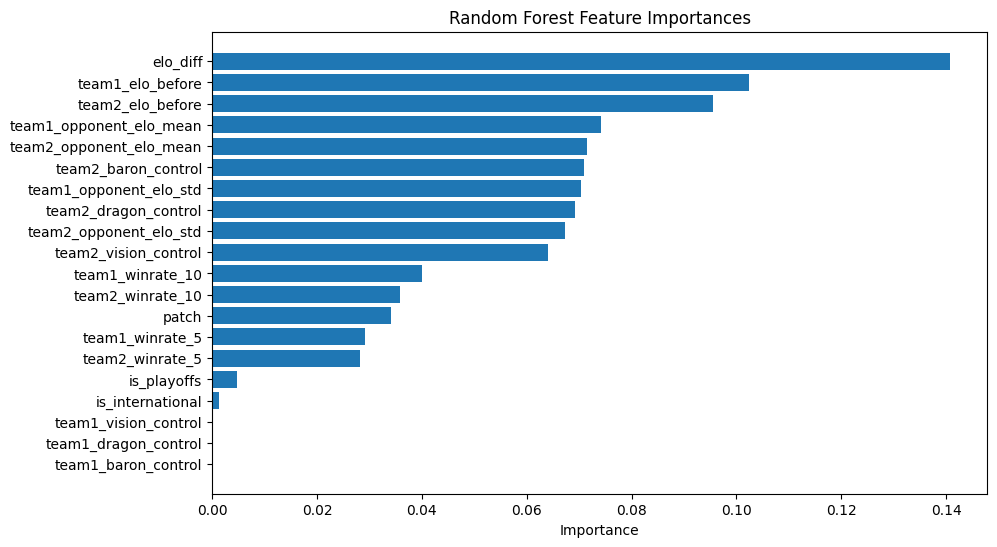

In [18]:
# Feature importance

import pandas as pd
import matplotlib.pyplot as plt

# Feltételezve, hogy a modell neve rf és a feature lista X.columns
importances = model.feature_importances_
feature_names = X.columns

# DataFrame-be pakoljuk
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

# Kiíratás
print(feat_imp)

# Vizu
plt.figure(figsize=(10,6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()  # a legfontosabb fent legyen
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances')
plt.show()

